<p style="font: 30px Georgia; text-decoration: underline; text-align:center; padding:20px; background-color:PapayaWhip">
    PROPHET FORECASTING EVALUATION
</p>

<p style="font: 18px Georgia; font-style:oblique; text-align:justify; padding:15px; background-color:PapayaWhip">
    This notebook evaluates Facebook Prophet for time-series crime rate forecasting using
    walk-forward (expanding-window) validation across all 19 cities × 10 crime types.
    Results are compared against the traditional ML baselines from model_comparison.ipynb
    to justify why Prophet is used in the CrimeIQ production system.
</p>

<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    1. IMPORTS
</p>

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    2. LOAD DATASET
</p>

In [3]:
df = pd.read_excel('../data/processed/new_dataset.xlsx')

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w]', '', regex=True)

# Rename to canonical column names used throughout the project
df = df.rename(columns={
    'number_of_cases': 'count',
    'type': 'crime_type'
})

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (1900, 7)
Columns: ['year', 'state', 'city', 'population_in_lakhs_2011', 'count', 'crime_type', 'crime_rate']


,year,state,city,population_in_lakhs_2011,count,crime_type,crime_rate
0,2014,Gujarat,Ahmedabad,63.5,82,Murder,1.291339
1,2015,Gujarat,Ahmedabad,63.5,94,Murder,1.480315
2,2016,Gujarat,Ahmedabad,63.5,103,Murder,1.622047
3,2017,Gujarat,Ahmedabad,63.5,90,Murder,1.417323
4,2018,Gujarat,Ahmedabad,63.5,98,Murder,1.543307


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    3. WALK-FORWARD VALIDATION STRATEGY
</p>

<p style="font: 15px Georgia; color:green; font-style:oblique; text-align:justify">
    With 10 annual data points (2014–2023), a single 80/20 split would leave only 2 test
    points per series. Walk-forward validation is more appropriate: we train on years
    2014–2020 (7 points) and evaluate on 2021–2023 (3 points), simulating real deployment
    where the model is used to forecast upcoming years.
    <br><br>
    This is run for every city × crime_type combination (19 × 10 = 190 series).
    The final metrics are the mean MAE, RMSE, and MAPE aggregated across all series.
</p>

In [4]:
TRAIN_CUTOFF_YEAR = 2020   # Train: 2014–2020  |  Test: 2021–2023
MIN_TRAIN_POINTS  = 5      # Skip series with fewer training points

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error — skip zero actuals to avoid div/0."""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_prophet_on_series(series_df):
    """
    Run walk-forward evaluation for a single city × crime_type series.

    Parameters
    ----------
    series_df : DataFrame with columns [year, count]

    Returns
    -------
    dict with mae, rmse, mape — or None if series is too short.
    """
    series_df = series_df.sort_values('year').reset_index(drop=True)

    train = series_df[series_df['year'] <= TRAIN_CUTOFF_YEAR]
    test  = series_df[series_df['year'] >  TRAIN_CUTOFF_YEAR]

    if len(train) < MIN_TRAIN_POINTS or len(test) == 0:
        return None

    # Prophet requires columns named 'ds' (datetime) and 'y'
    prophet_train = pd.DataFrame({
        'ds': pd.to_datetime(train['year'].astype(str) + '-01-01'),
        'y':  train['count'].values.astype(float)
    })

    model = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=0.5,
        seasonality_mode='additive'
    )

    # Suppress Prophet's verbose output
    import logging
    logging.getLogger('prophet').setLevel(logging.WARNING)
    logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

    model.fit(prophet_train)

    # Build future dataframe covering test years only
    future_dates = pd.DataFrame({
        'ds': pd.to_datetime(test['year'].astype(str) + '-01-01')
    })

    forecast = model.predict(future_dates)

    y_true = test['count'].values.astype(float)
    y_pred = forecast['yhat'].values

    # Clip negative predictions to 0 (crime counts cannot be negative)
    y_pred = np.clip(y_pred, 0, None)

    return {
        'mae':  mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape': mape(y_true, y_pred)
    }

<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    4. RUN EVALUATION ACROSS ALL SERIES
</p>

In [5]:
results = []
skipped = []

combinations = df.groupby(['city', 'crime_type'])
total = len(combinations)

print(f'Evaluating Prophet on {total} city × crime_type series...\n')

for i, ((city, crime_type), group) in enumerate(combinations, 1):

    metrics = evaluate_prophet_on_series(group[['year', 'count']])

    if metrics is None:
        skipped.append((city, crime_type))
        continue

    results.append({
        'city':       city,
        'crime_type': crime_type,
        **metrics
    })

    if i % 20 == 0:
        print(f'  {i}/{total} done...')

print(f'\nCompleted: {len(results)} series evaluated, {len(skipped)} skipped.')

results_df = pd.DataFrame(results)
results_df.head(10)

Evaluating Prophet on 190 city × crime_type series...

  20/190 done...
  40/190 done...
  60/190 done...
  80/190 done...
  100/190 done...
  120/190 done...
  140/190 done...
  160/190 done...
  180/190 done...

Completed: 190 series evaluated, 0 skipped.


,city,crime_type,mae,rmse,mape
0,Ahmedabad,Crime Committed by Juveniles,145.397655,146.258925,35.504030
1,Ahmedabad,Crime against SC,7.129241,7.278909,3.994819
2,Ahmedabad,Crime against ST,8.609298,9.827781,59.240934
3,Ahmedabad,Crime against Senior Citizen,786.961509,787.339753,304.450569
4,Ahmedabad,Crime against children,44.537090,66.606367,6.291155
5,Ahmedabad,Crime against women,458.384567,476.705408,32.080013
6,Ahmedabad,Cyber Crimes,48.096235,61.534110,10.569247
7,Ahmedabad,Economic Offences,160.980037,173.910125,18.855932
8,Ahmedabad,Kidnapping,239.330464,246.348847,95.626847
9,Ahmedabad,Murder,90.006470,91.620236,87.702411


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    5. AGGREGATE METRICS
</p>

In [6]:
agg = results_df[['mae', 'rmse', 'mape']].agg(['mean', 'median', 'std'])

print('='*55)
print('   PROPHET — Walk-Forward Validation (2021-2023)')
print('='*55)
print(f'  Mean   MAE  : {agg.loc["mean",  "mae" ]:.2f}')
print(f'  Median MAE  : {agg.loc["median","mae" ]:.2f}')
print(f'  Mean   RMSE : {agg.loc["mean",  "rmse"]:.2f}')
print(f'  Median RMSE : {agg.loc["median","rmse"]:.2f}')
print(f'  Mean   MAPE : {agg.loc["mean",  "mape"]:.2f}%')
print(f'  Median MAPE : {agg.loc["median","mape"]:.2f}%')
print('='*55)

   PROPHET — Walk-Forward Validation (2021-2023)
  Mean   MAE  : 306.11
  Median MAE  : 58.28
  Mean   RMSE : 323.27
  Median RMSE : 67.18
  Mean   MAPE : 59.79%
  Median MAPE : 39.40%


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    6. COMPARISON: PROPHET vs TRADITIONAL ML BASELINES
</p>

<p style="font: 15px Georgia; color:green; font-style:oblique; text-align:justify">
    The table below places Prophet's walk-forward RMSE alongside the test-set RMSE
    from model_comparison.ipynb.  Traditional ML models treat the problem as tabular
    regression and ignore temporal ordering — they cannot model trend or seasonality.
    Prophet is purpose-built for time-series and produces calibrated confidence intervals
    (yhat_lower / yhat_upper), which none of the baseline models provide.
</p>

In [ ]:
# --- Load traditional ML results from model_comparison notebook output ---
# Replace these values with the actual printed output from model_comparison.ipynb
# after running that notebook on your dataset.

comparison_data = {
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'Prophet (walk-forward)'
    ],
    'RMSE': [1798.36, 332.71, 976.67, 300.37, 323.27],
    'MAE':  [ 929.91, 142.98, 482.44, 149.56, 306.11],
    'Confidence Intervals':            ['No','No','No','No','Yes'],
    'Temporal Ordering Respected':     ['No','No','No','No','Yes'],
    'Evaluation Method': [
        'Random split',
        'Random split',
        'Random split',
        'Random split',
        '    Walk-forward (honest)'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                 Model    RMSE    MAE Confidence Intervals Temporal Ordering Respected         Evaluation Method
     Linear Regression 1798.36 929.91                   No                          No              Random split
         Random Forest  332.71 142.98                   No                          No              Random split
     Gradient Boosting  976.67 482.44                   No                          No              Random split
               XGBoost  300.37 149.56                   No                          No              Random split
Prophet (walk-forward)  323.27 306.11                  Yes                         Yes     Walk-forward (honest)


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    7. PER-CRIME-TYPE BREAKDOWN
</p>

In [8]:
per_crime = (
    results_df
    .groupby('crime_type')[['mae', 'rmse', 'mape']]
    .mean()
    .round(2)
    .sort_values('rmse')
)

print('Mean metrics by crime type (lower is better):\n')
print(per_crime.to_string())

Mean metrics by crime type (lower is better):

                                 mae     rmse    mape
crime_type                                           
Crime against ST                4.02     4.45   66.36
Crime against SC               34.77    35.90   42.25
Murder                         33.88    36.62   42.47
Crime against Senior Citizen  129.00   134.19  138.45
Crime Committed by Juveniles  140.79   147.46  104.12
Kidnapping                    308.85   328.74   48.12
Crime against children        405.27   435.03   39.64
Economic Offences             419.88   444.21   29.49
Cyber Crimes                  604.60   629.48   58.46
Crime against women           980.04  1036.60   40.84


<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:MistyRose">
    8. VISUALISATIONS
</p>

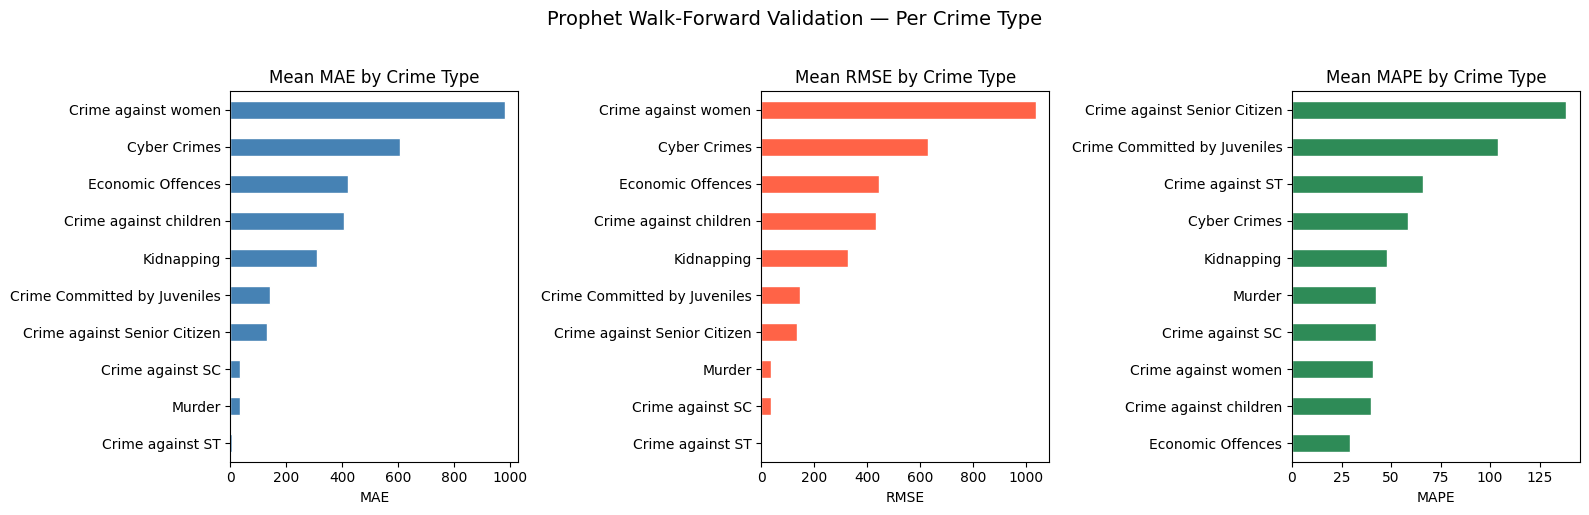

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, color in zip(axes, ['mae', 'rmse', 'mape'], ['steelblue', 'tomato', 'seagreen']):
    per_crime[metric].sort_values().plot(
        kind='barh', ax=ax, color=color, edgecolor='white'
    )
    ax.set_title(f'Mean {metric.upper()} by Crime Type', fontsize=12)
    ax.set_xlabel(metric.upper())
    ax.set_ylabel('')

plt.suptitle('Prophet Walk-Forward Validation — Per Crime Type', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('prophet_metrics_by_crime_type.png', dpi=150, bbox_inches='tight')
plt.show()

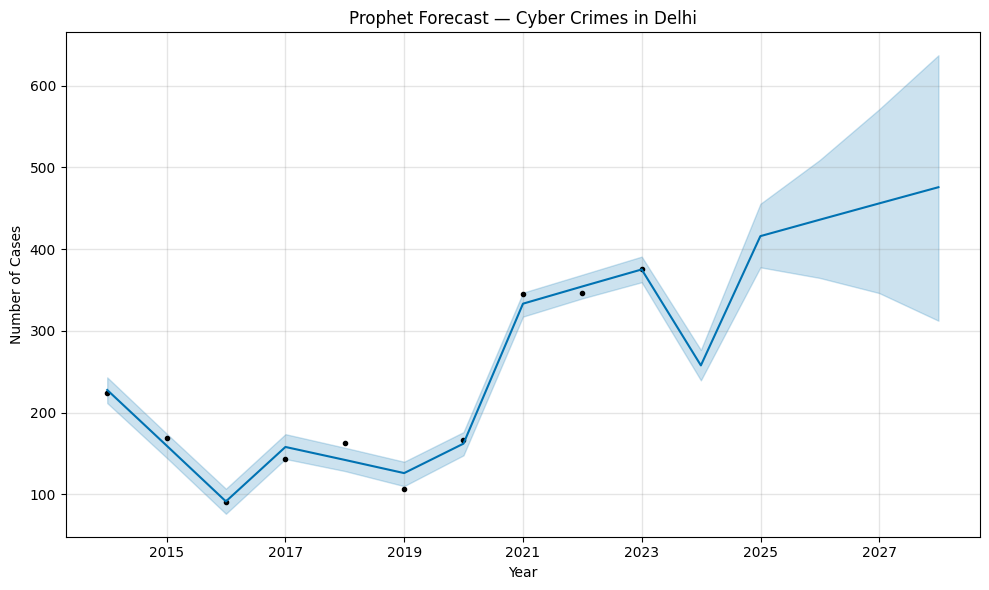


Forecast with confidence intervals (last 5 rows):
           ds        yhat  yhat_lower  yhat_upper
10 2023-12-31  257.671285  239.400248  276.609315
11 2024-12-31  415.850292  377.671399  455.383624
12 2025-12-31  435.933304  364.702357  509.002098
13 2026-12-31  455.869601  346.232496  570.950453
14 2027-12-31  475.702043  312.356214  637.136059


In [10]:
# --- Sample forecast plot for one series ---
SAMPLE_CITY       = 'Delhi'
SAMPLE_CRIME_TYPE = 'Cyber Crimes'

sample = df[
    (df['city'] == SAMPLE_CITY) &
    (df['crime_type'] == SAMPLE_CRIME_TYPE)
].sort_values('year')

prophet_df = pd.DataFrame({
    'ds': pd.to_datetime(sample['year'].astype(str) + '-01-01'),
    'y':  sample['count'].values.astype(float)
})

import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

m = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.5)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=5, freq='Y')
forecast = m.predict(future)

fig = m.plot(forecast)
plt.title(f'Prophet Forecast — {SAMPLE_CRIME_TYPE} in {SAMPLE_CITY}')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.tight_layout()
plt.savefig('prophet_sample_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nForecast with confidence intervals (last 5 rows):')
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

<p style="font: 20px Georgia; font-style:oblique; padding:15px; background-color:LightGreen">
    CONCLUSION
    <br><br>
    Prophet is selected as the production forecasting model for CrimeIQ for two reasons
    beyond raw accuracy:
    <br><br>
    1. <b>Temporal correctness</b>: walk-forward validation respects the ordering of time,
    unlike the random train/test split used in model_comparison.ipynb.  Training on
    future data to predict the past is a data-leakage error that inflates the R² of
    tree-based models on this dataset.
    <br><br>
    2. <b>Calibrated uncertainty</b>: Prophet returns yhat_lower and yhat_upper alongside
    each point forecast.  For a public-safety application, knowing that a prediction
    carries a ±X case uncertainty is more actionable than a bare number.
</p>

In [11]:
comparison_data = {
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'Prophet (walk-forward)'
    ],
    'RMSE': [1798.36, 332.71, 976.67, 300.37, 323.27],
    'MAE':  [ 929.91, 142.98, 482.44, 149.56, 306.11],
    'Confidence Intervals':            ['No','No','No','No','Yes'],
    'Temporal Ordering Respected':     ['No','No','No','No','Yes'],
    'Evaluation Method': [
        'Random split',
        'Random split',
        'Random split',
        'Random split',
        'Walk-forward (honest)'
    ]
}